In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/reg_mixer_attnpl_t_20260131-112552") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {'fuse_mode': 'concat', 'use_ln': True, 'use_var_scale': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'reg_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 2, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size

OptimizedModule(
  (_orig_mod): TaskModel(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_linear): Linear(in_features=1, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (conv1d): Conv1d(384, 384, kernel_size=(4,), stride=(1,), padding=(3,), groups=384)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
              (fc1): Linear(in_features=64, out_features=256, bias=False)

In [3]:
model.eval()
model.extractor.g

Parameter containing:
tensor([0.0057, 0.0111, 0.0038, 0.0078], device='cuda:0', requires_grad=True)

In [4]:
torch.min(model.base_model.encoder.input_linear.bias)

tensor(-0.0215, device='cuda:0', grad_fn=<MinBackward1>)

In [5]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/regressor/regressor_Mc_3_Mf_3_Tfore_180_Twindow_360_context_le

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [7]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

In [21]:
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    

In [23]:
model.base_model.input_adapter(x)['features'][0,:,0]

tensor([3.2000, 3.0000, 3.1000, 3.2000, 3.0000, 3.0000, 3.3000, 3.5000, 3.1000,
        3.4000, 3.5000, 3.0000, 3.1000, 3.1000, 3.0000, 3.5000, 3.1000, 4.0000,
        3.5000, 3.4000, 3.3000, 3.0000, 3.9000, 4.2000, 3.2000, 3.0000, 3.5000,
        3.4000, 3.7000, 3.0000, 4.1000, 3.5000, 3.0000, 3.6000, 3.4000, 3.7000,
        3.3000, 4.1000, 5.1000, 3.7000, 4.0000, 3.1000, 3.4000, 3.5000, 5.0000,
        3.0000, 3.4000, 3.0000, 3.0000, 3.3000, 3.1000, 4.3000, 3.4000, 3.2000,
        3.4000, 4.1000, 3.0000, 3.2000, 3.4000, 3.4000, 3.2000, 3.1000, 3.0000,
        3.1000, 3.5000, 3.1000, 3.1000, 4.1000, 3.5000, 3.0000, 3.0000, 3.3000,
        3.2000, 3.1000, 3.3000, 3.0000, 3.2000, 3.3000, 3.0000, 3.9000, 3.7000,
        3.2000, 3.1000, 3.0000, 3.3000, 3.1000, 3.7000, 3.2000, 3.1000, 3.3000,
        3.3000, 3.3000, 3.1000, 3.4000, 3.5000, 3.1000, 3.0000, 3.3000, 3.0000,
        3.1000, 3.1000, 3.0000, 4.6000, 3.4000, 3.6000, 3.2000, 3.0000, 3.1000,
        3.5000, 3.8000, 3.0000, 3.4000, 

In [19]:
model.base_model.encoder.layers[0]

Block(
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mixer): Mamba2Rotary(
    (in_proj): Linear(in_features=64, out_features=514, bias=False)
    (conv1d): Conv1d(384, 384, kernel_size=(4,), stride=(1,), padding=(3,), groups=384)
    (act): SiLU()
    (norm): RMSNorm()
    (out_proj): Linear(in_features=128, out_features=64, bias=False)
    (rotary_emb): RotaryEmbeddingTime()
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mlp): GatedMLP(
    (fc1): Linear(in_features=64, out_features=256, bias=False)
    (fc2): Linear(in_features=128, out_features=64, bias=False)
  )
)

In [ ]:
# GitHub Copilot

# Capture activations after encoder layer[0] and visualize distribution
layer0_out = []

def _hook(module, inp, out):
    # out shape expected: (B, L, D)
    layer0_out.append(out.detach())

hook_handle = model.base_model.encoder.layers[0].register_forward_hook(_hook)

with torch.no_grad():
    _ = model(x)  # uses existing batch `x` on device

# Remove hook
hook_handle.remove()

# Get captured output
if len(layer0_out) > 0:
    h = layer0_out[0]  # first (and only) batch
    # Global stats
    h_mean = h.mean().item()
    h_std = h.std().item()
    h_min = h.min().item()
    h_max = h.max().item()
    print(f"Layer[0] activations -> mean: {h_mean:.4f}, std: {h_std:.4f}, min: {h_min:.4f}, max: {h_max:.4f}")

    # Per-channel mean (D)
    channel_means = h.mean(dim=(0, 1)).detach().cpu().numpy()

    # Flatten for histogram
    h_flat = h.reshape(-1).detach().cpu().numpy()

    # Plots
    fig_dist, axs_dist = plt.subplots(1, 2, figsize=(12, 4))
    axs_dist[0].hist(h_flat, bins=100, color="steelblue", alpha=0.8)
    axs_dist[0].set_title("Layer[0] activation histogram")
    axs_dist[0].set_xlabel("Activation value")
    axs_dist[0].set_ylabel("Count")

    axs_dist[1].plot(channel_means, marker="o", ms=3)
    axs_dist[1].set_title("Per-channel mean (Layer[0])")
    axs_dist[1].set_xlabel("Channel index")
    axs_dist[1].set_ylabel("Mean activation")
    plt.tight_layout()
    plt.show()
else:
    print("No activations captured from layer[0].")

In [13]:
model.eval()
model.extractor.t_mlp.to(device)
x = torch.linspace(0, 1, 100).unsqueeze(1)  
x = x.to(device)  
gamma, beta = model.extractor.t_mlp(x).chunk(2, dim=-1)  

In [14]:
def predict_all(model, data_loader, device, return_X=False):
    y_pred_list = []
    y_list = []
    X_list = [] if return_X else None

    model.eval()
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            if return_X:
                X = model.get_pooled_representation(x)
                X_list.append(X.detach().cpu())
            y_pred = model(x)
            y_pred_list.append(y_pred.detach().cpu())
            y_list.append(y.detach().cpu())

    y_pred_all = torch.cat(y_pred_list, dim=0).cpu().numpy()
    # flatten if shape is (N,1)
    if y_pred_all.ndim == 2 and y_pred_all.shape[1] == 1:
        y_pred_all = y_pred_all.squeeze(1)
    y_all = torch.cat(y_list, dim=0).cpu().numpy()

    if return_X:
        X_all = torch.cat(X_list, dim=0).cpu().numpy()
        return y_pred_all,  y_all, X_all
    return y_pred_all, y_all, None

In [15]:
from src.utils.metrics import regression_metrics, log_metrics, plot_and_save_roc_curve
y_pred_all, y_all, X_all = predict_all(model,val_loader, device, return_X=True)
start=0
end =400
regression_metrics(y_all[start:end], y_pred_all[start:end])  

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0201 21:09:14.210000 3998 site-packages/torch/_dynamo/convert_frame.py:844] [3/8] torch._dynamo hit config.cache_size_limit (8)
W0201 21:09:14.210000 3998 site-packages/torch/_dynamo/convert_frame.py:844] [3/8]    function: 'forward' (/root/autodl-tmp/chuandian_eq/src/models/mamba/block.py:43)
W0201 21:09:14.210000 3998 site-packages/torch/_dynamo/convert_frame.py:844] [3/8]    last reason: 3/0: ___check_obj_id(L['residual'], 9667616)                     
W0201 21:09:14.210000 3998 site-packages/torch/_dynamo/convert_frame.py:844] [3/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0201 21:09:14.210000 3998 site-packages/torch/_dynamo/convert_frame.py:844] [3/8] To diagnose recompilation

{'RMSE': 0.12206465001411268,
 'MAE': 0.10250015278438945,
 'MSE': 0.014899778783067818,
 'MAPE': 25.433631210807086,
 'R2': 0.10271030426818872,
 'PearsonR': 0.3848967644928642,
 'PearsonR_diff': -0.20726546514483937,
 'DA': 0.04419889502762431,
 'SpearmanR': 0.30543366250765963,
 'SpearmanR_diff': -0.03806018117857579,
 'DTW': 15.255494475364685,
 'DTW_normalized': 0.08382139821628948}

/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


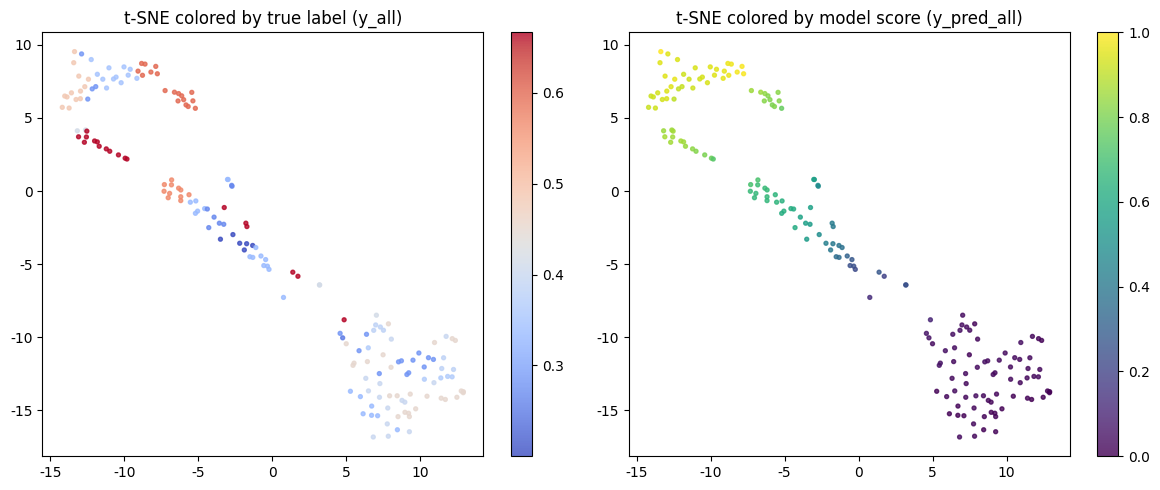

In [16]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# prepare features
X = X_all.astype(float)
X_scaled = StandardScaler().fit_transform(X)

# run t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=0)
X_tsne = tsne.fit_transform(X_scaled)

# normalize predictions for coloring
y_score = (y_pred_all - y_pred_all.min()) / (y_pred_all.max() - y_pred_all.min())

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axs[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_all, cmap="coolwarm", s=8, alpha=0.8)
axs[0].set_title("t-SNE colored by true label (y_all)")
plt.colorbar(sc0, ax=axs[0])

sc1 = axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_score, cmap="viridis", s=8, alpha=0.8)
axs[1].set_title("t-SNE colored by model score (y_pred_all)")
plt.colorbar(sc1, ax=axs[1])

plt.tight_layout()
plt.show()

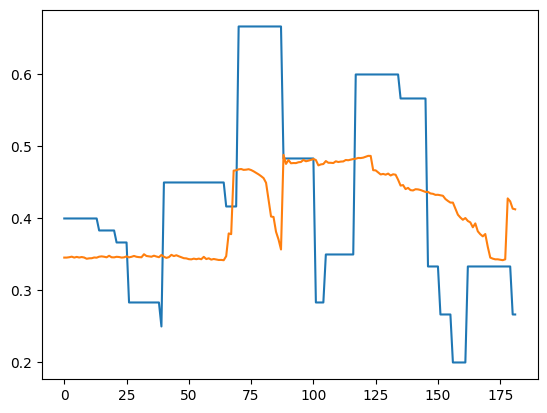

In [17]:
plt.plot(y_all,)
plt.plot(y_pred_all)